# 0. Configuration

In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize,Bounds,minimize_scalar
import statsmodels

import matplotlib.pyplot as plt
import seaborn as sns
  

/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# 1. Load Data

In [6]:
search_df = pd.read_csv('search_marketplace.csv')
search_df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,4/4/2013 8:32,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,4/4/2013 8:32,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,4/4/2013 8:32,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,4/4/2013 8:32,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,4/4/2013 8:32,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [7]:
# View the column names in the DataFrame
search_df.columns

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

# 2. Exploratory Data Analysis

Data Cleaning: 
- handle null values
- remove outliers
- create new variables
- drop unnecessary columns
- create new features

Clean data while exploring key characteristics:
- **outcomes**: click_bool, booking_bool

- **visitor**: visitor_hist_starrating, visitor_hist_adr_usd

- **property characteristics**: prop_starrating, prop_review_score, prop_brand_bool, prop_location_score1, prop_location_score2, prop_log_historical_price, position, price_usd, promotion_flag

- **search**: srch_length_of_stay, srch_booking_window, srch_adults_count, srch_children_count, srch_room_count, srch_saturday_night_bool, srch_query_affinity_score

- **competitor information**: comp1_rate~comp8_rate



**outcomes**

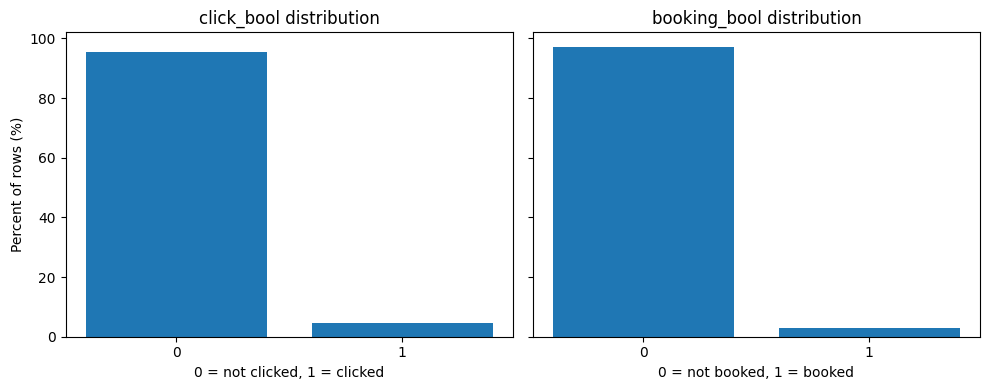

In [ ]:
import matplotlib.pyplot as plt

click = search_df['click_bool'].astype(int)
book  = search_df['booking_bool'].astype(int)

click_pct = click.value_counts(normalize=True).sort_index() * 100
book_pct  = book.value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(click_pct.index.astype(str), click_pct.values)
axes[0].set_title("click_bool distribution")
axes[0].set_xlabel("0 = not clicked, 1 = clicked")
axes[0].set_ylabel("Percent of rows (%)")

axes[1].bar(book_pct.index.astype(str), book_pct.values)
axes[1].set_title("booking_bool distribution")
axes[1].set_xlabel("0 = not booked, 1 = booked")

plt.tight_layout()
plt.show()


In [ ]:
click_rate = round(search_df["click_bool"].mean()*100,2)
book_rate  = round(search_df["booking_bool"].mean()*100,2)

clicked = search_df[search_df["click_bool"] == 1]*100
p_book_given_click = round(clicked["booking_bool"].mean() if len(clicked) else np.nan,2)


print(f"Average Click rate is {click_rate} %")
print(f"Average Booking rate is {book_rate} %")
print(f"Average Conversion from click to book rate is {p_book_given_click} %")


Average Click rate is 4.48 %
Average Booking rate is 2.8 %
Average Conversion from click to book rate is 62.53 %


**visitors**

In [ ]:
search_df[['visitor_hist_starrating','visitor_hist_adr_usd']].isnull().sum()

visitor_hist_starrating    189169
visitor_hist_adr_usd       189141
dtype: int64

In [ ]:
# visitor_hist_starrating & visitor_hist_adr_usd have too many missing values; create new variable and drop
search_df['has_history'] = search_df['visitor_hist_starrating'].notnull().astype(int)

search_df = search_df.drop(columns=['visitor_hist_starrating','visitor_hist_adr_usd'])

**property characteristics**

In [ ]:
# get basic stats for property characteristics

property = search_df.iloc[:,6:15]
property.describe()

,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag
count,200000.000000,199719.000000,200000.000000,200000.000000,156405.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,3.197935,3.798810,0.641310,2.888441,0.131871,4.337861,16.861115,182.622906,0.214590
std,1.050292,1.026984,0.479617,1.536571,0.160326,1.831662,10.433155,1653.977776,0.410539
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.370000,0.000000
25%,3.000000,3.500000,0.000000,1.790000,0.019600,4.460000,8.000000,86.710000,0.000000
50%,3.000000,4.000000,1.000000,2.770000,0.069700,4.930000,16.000000,125.000000,0.000000
75%,4.000000,4.500000,1.000000,4.060000,0.182900,5.330000,26.000000,188.000000,0.000000
max,5.000000,5.000000,1.000000,6.980000,1.000000,6.210000,40.000000,250892.000000,1.000000


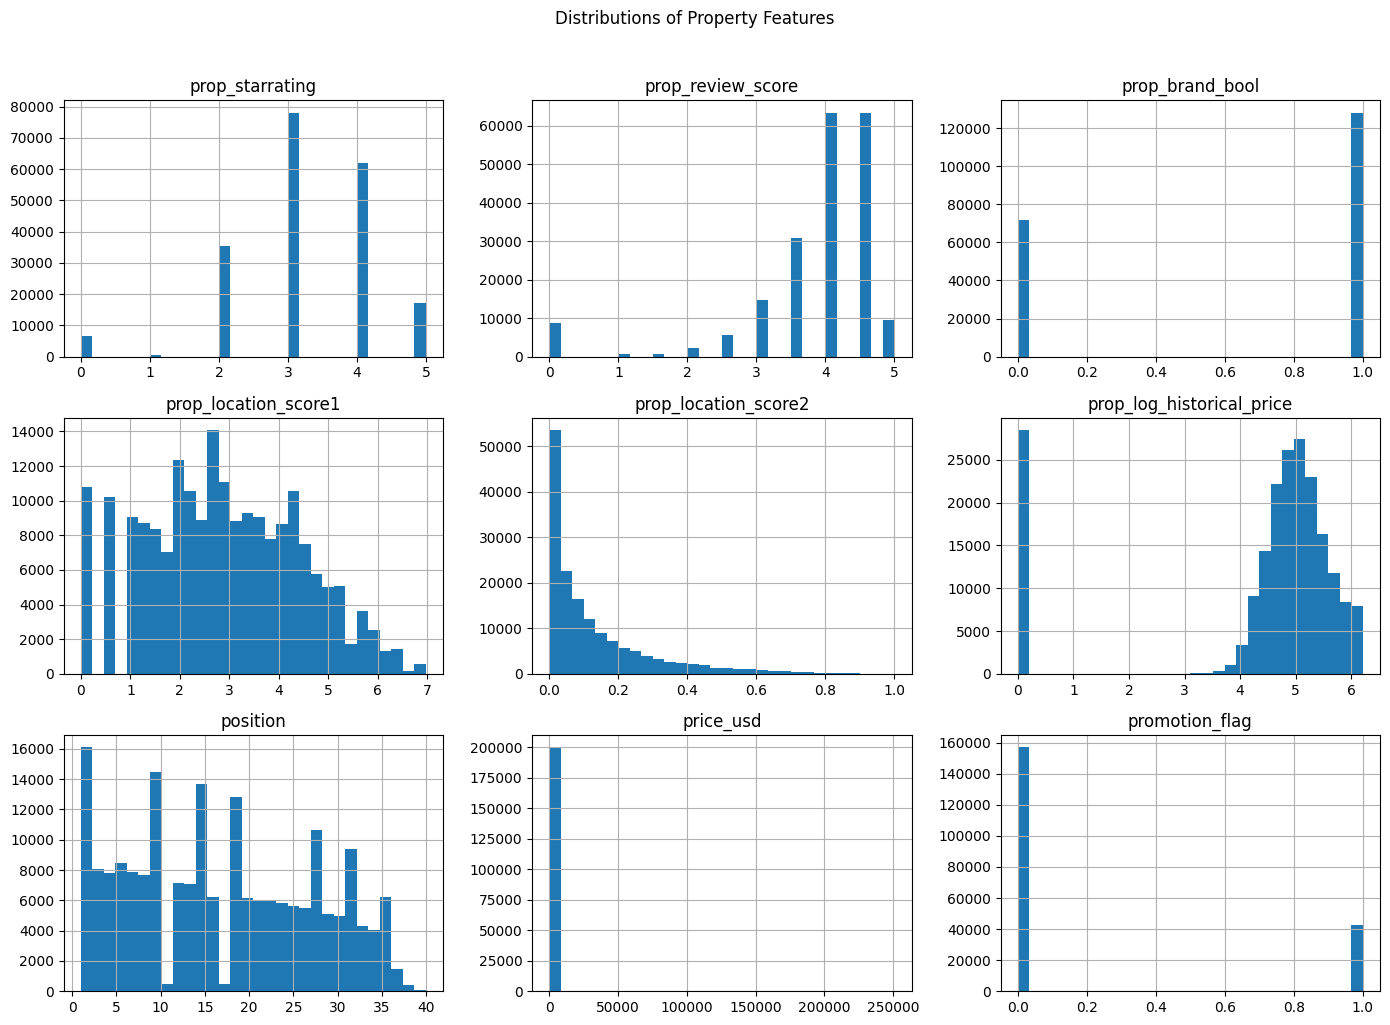

In [190]:
# visualize 
property_cols = property.columns.tolist()

property[property_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Distributions of Property Features", y=1.02)
plt.tight_layout()
plt.show()



In [ ]:
# outliers: from describe and visualization, price has outliers -> cap outliers 

search_df["price_usd"] = pd.to_numeric(search_df["price_usd"], errors="coerce")

lo, hi = search_df["price_usd"].quantile([0.01, 0.99])
search_df["price_usd"] = search_df["price_usd"].clip(lo, hi)

(lo, hi)


(34.0999, 623.1606000000005)

In [192]:
# see missing data for property characteristics
property.isnull().sum()

prop_starrating                  0
prop_review_score              281
prop_brand_bool                  0
prop_location_score1             0
prop_location_score2         43595
prop_log_historical_price        0
position                         0
price_usd                        0
promotion_flag                   0
dtype: int64

In [ ]:
# prop_location_score2 don't seem to follow the pattern of prop_location_score_1, impute missing values with median 

search_df['prop_location_score2'] = search_df['prop_location_score2'].fillna(search_df['prop_location_score2'].median())

# for rest, 

In [ ]:
# fill na with mean for property review score (exclude 0 because it means no review available)
search_df["prop_review_score"] = round(pd.to_numeric(search_df["prop_review_score"], errors="coerce"),1)

mean_review = search_df.loc[search_df["prop_review_score"].notna() & (search_df["prop_review_score"] > 0),
                        "prop_review_score"].mean()

search_df["prop_review_score"] = search_df["prop_review_score"].fillna(mean_review)

Is click & booking rate higher for higher rated reviews?

In [ ]:
# total clicks + bookings per star rating
clicks_per_reviews   = search_df.groupby('prop_review_score')['click_bool'].sum().sort_index()
bookings_per_reviews = search_df.groupby('prop_review_score')['booking_bool'].sum().sort_index()

# get star rating distribution 
prop_reviews_counts = search_df['prop_review_score'].value_counts().sort_index()

# click/booking rate (%) per star rating (denominator = impressions per star)
click_rate_pct   = round((clicks_per_reviews * 100 / prop_reviews_counts),2).rename("click_rate")
booking_rate_pct = round((bookings_per_reviews * 100 / prop_reviews_counts),2).rename("booking_rate")

rates_df = pd.concat([click_rate_pct, booking_rate_pct], axis=1).reset_index()

rates_df = rates_df.rename(columns={"prop_review_score": "review score"})
rates_df


,review score,click_rate,booking_rate
0,0.000000,2.99,1.22
1,1.000000,1.45,0.36
2,1.500000,2.17,0.36
3,2.000000,2.46,1.46
4,2.500000,3.45,1.65
5,3.000000,3.47,1.97
6,3.500000,4.53,2.91
7,3.973762,4.27,2.14
8,4.000000,5.05,3.31
9,4.500000,4.70,2.97


- Click rate generally increases as review score rises from 1.0 to 4.0 (peaks at 5.05% at 4.0), then declines at 4.5 (4.70%) and 5.0 (3.36%).

- Booking rate follows the same pattern (peaks at 3.31% at 4.0), then declines at 4.5 (2.97%) and 5.0 (1.95%).

- The “0.0” review-score bucket behaves differently (often “no reviews” or special coding), so it should be treated as its own category rather than “worst quality.”

Is click & booking rate higher for higher star-rated properties?

In [ ]:
# total clicks + bookings per star rating
clicks_per_star   = search_df.groupby('prop_starrating')['click_bool'].sum().sort_index()
bookings_per_star = search_df.groupby('prop_starrating')['booking_bool'].sum().sort_index()

# get star rating distribution 
prop_star_counts = search_df['prop_starrating'].value_counts().sort_index()

# click/booking rate (%) per star rating (denominator = impressions per star)
click_rate_pct   = round((clicks_per_star * 100 / prop_star_counts),2).rename("click_rate")
booking_rate_pct = round((bookings_per_star * 100 / prop_star_counts),2).rename("booking_rate")

rates_df = pd.concat([click_rate_pct, booking_rate_pct], axis=1).reset_index()

rates_df = rates_df.rename(columns={"prop_starrating": "star"})
rates_df


,star,click_rate,booking_rate
0,0,2.99,1.61
1,1,2.26,0.75
2,2,3.33,2.09
3,3,4.46,2.86
4,4,5.34,3.36
5,5,4.49,2.49


- Click and booking rates increase from rating 1 through rating 4 (peak at 5.34% click and 3.36% booking at rating 4), then drop at rating 5 (4.49% click, 2.49% booking).

- A common reason for the rating-5 drop is confounding (especially higher prices and/or different average positions/exposure).

Is click & booking rate higher for higher priced properties?

In [ ]:
# create copy for exploratory
df = search_df.copy()

df["price_decile"] = pd.qcut(df["price_usd"], q=10, duplicates="drop")

price_summary = (
    df.groupby("price_decile")
      .agg(
          impressions=("price_usd", "size"),
          avg_price=("price_usd", "mean"),
          total_clicks=("click_bool", "sum"),
          total_bookings=("booking_bool", "sum")
      )
      .assign(
          click_rate=lambda d: 100 * d["total_clicks"] / d["impressions"],
          booking_rate=lambda d: 100 * d["total_bookings"] / d["impressions"],
          booking_given_click=lambda d: np.where(d["total_clicks"]>0, 100*d["total_bookings"]/d["total_clicks"], np.nan)
      )
      .reset_index()
)

price_summary[["price_decile","impressions","avg_price","click_rate","booking_rate","booking_given_click"]]


/var/folders/pp/n1knqjg57ds10zbbb7v7yvfw0000gn/T/ipykernel_19099/4037337523.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_decile")


,price_decile,impressions,avg_price,click_rate,booking_rate,booking_given_click
0,"(34.099000000000004, 62.0]",20117,50.233030,4.389322,2.898046,66.024915
1,"(62.0, 79.0]",20602,71.259633,4.373362,2.970585,67.924528
2,"(79.0, 94.0]",19971,86.736066,4.937159,3.259727,66.024341
3,"(94.0, 109.0]",21309,101.874897,5.087052,3.524332,69.280443
4,"(109.0, 125.0]",18760,117.119324,4.845416,3.182303,65.676568
5,"(125.0, 144.07]",19247,134.358260,5.268354,3.325194,63.116371
6,"(144.07, 169.27]",19995,156.787221,4.626157,2.830708,61.189189
7,"(169.27, 208.33]",20001,187.506857,4.124794,2.449878,59.393939
8,"(208.33, 280.0]",20044,239.714568,4.051088,2.175215,53.694581
9,"(280.0, 623.161]",19954,398.658471,3.082089,1.368147,44.390244


- Click rate peaks in the mid-price range, then declines at high prices.
- Click rate rises from 4.39% in first decile to a maximum of 5.27% around the middle-upper deciles (avg price 134), then falls steadily to 3.08% in the top decile (avg price 399).

- Booking rate is highest in the mid-price range, then drops sharply at high prices.
- Booking rate reaches its maximum at decile 3 (3.52%, avg price 102) and declines to 1.37% in the top decile.

- Booking given click declines monotonically as price increases.
- Conversion after interest drops from roughly 66–69% in lower/mid deciles to 44.39% in the top decile.
- This is consistent with price sensitivity: expensive listings can still attract some clicks, but are much less likely to convert into bookings.

In [ ]:
# create new feature price_decile and replace existing price_usd
search_df["price_decile"] = pd.qcut(search_df["price_usd"], q=10, duplicates="drop")

**search**

In [8]:
search = search_df[['srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score']]

search.describe()

,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,12703.000000
mean,2.375430,38.532440,1.959575,0.351665,1.102585,0.498485,-23.974649
std,2.048115,53.341799,0.832012,0.722807,0.381093,0.499999,15.709783
min,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,-143.331300
25%,1.000000,4.000000,2.000000,0.000000,1.000000,0.000000,-30.995200
50%,2.000000,17.000000,2.000000,0.000000,1.000000,0.000000,-20.147800
75%,3.000000,50.000000,2.000000,0.000000,1.000000,1.000000,-12.999550
max,28.000000,467.000000,9.000000,6.000000,8.000000,1.000000,-3.662500


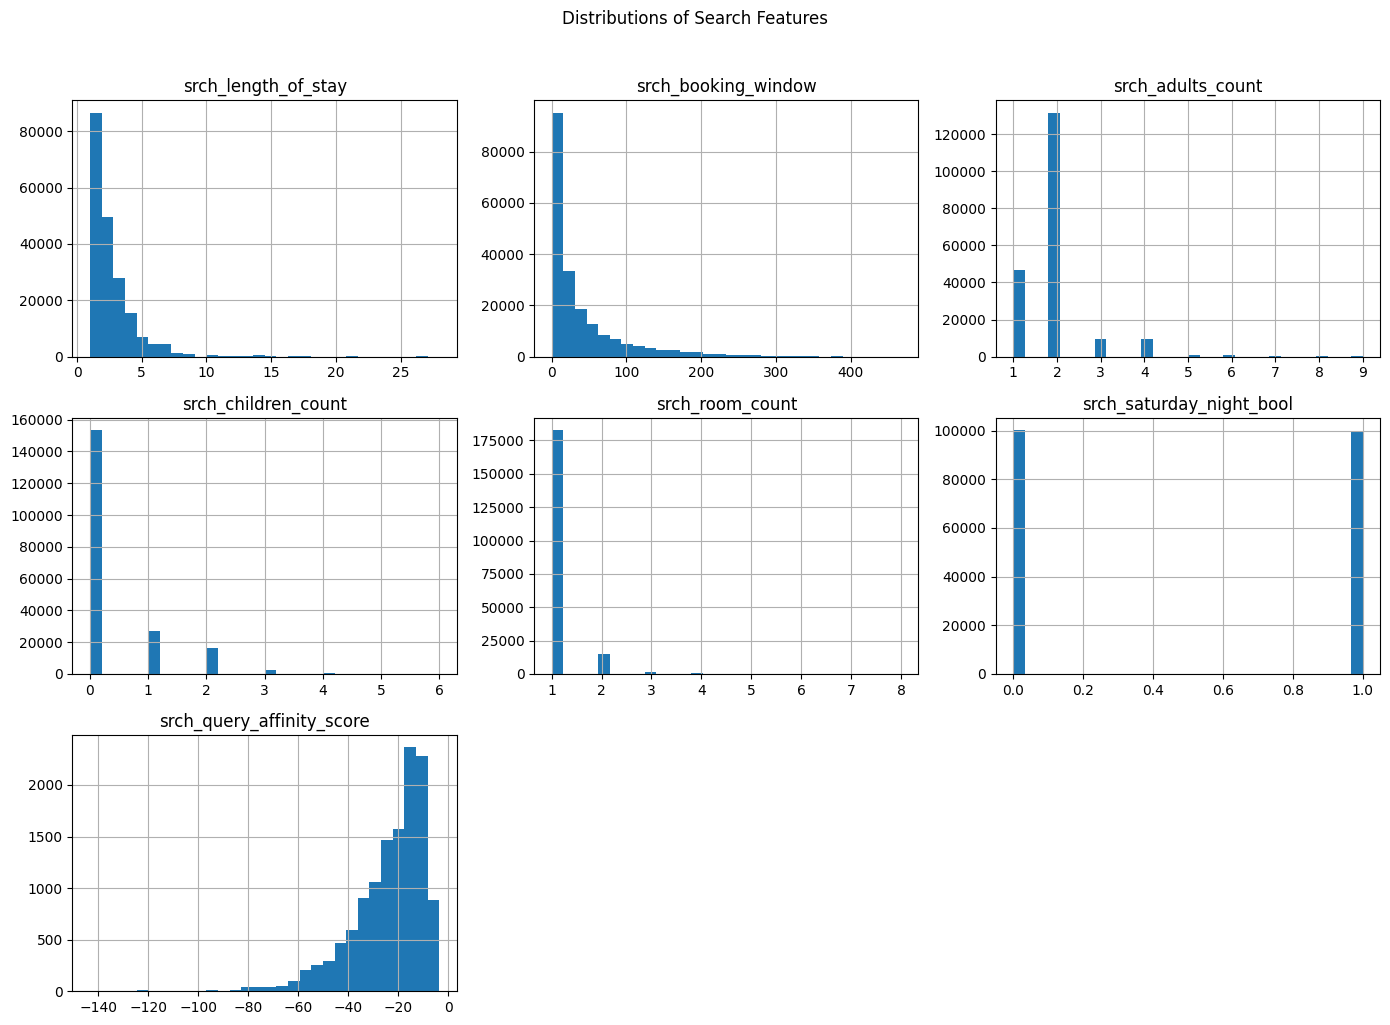

In [200]:
# visualize 
search_cols = search.columns.tolist()

search[search_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Distributions of Search Features", y=1.02)
plt.tight_layout()
plt.show()



# 3. Data Cleaning

In [9]:
# missing values: 
search.isnull().sum()
# srch_query_affinity score 

srch_length_of_stay               0
srch_booking_window               0
srch_adults_count                 0
srch_children_count               0
srch_room_count                   0
srch_saturday_night_bool          0
srch_query_affinity_score    187297
dtype: int64

In [ ]:
# impute affinity score with median of non missing values 
aff_med = search_df["srch_query_affinity_score"].median(skipna=True)

search_df["srch_query_affinity_score"] = search_df["srch_query_affinity_score"].fillna(aff_med)


# 4. Feature Engineering

In [ ]:
search_df["total_guests"] = search_df["srch_adults_count"] + search_df["srch_children_count"]

search_df["party_type"] = np.select(
    [
        search_df["srch_children_count"].fillna(0) > 0,
        (search_df["srch_children_count"].fillna(0) == 0) & (search_df["total_guests"] == 1),
        (search_df["srch_children_count"].fillna(0) == 0) & (search_df["total_guests"] == 2),
        (search_df["srch_children_count"].fillna(0) == 0) & (search_df["total_guests"] >= 3),
    ],
    ["family", "solo", "couple", "group"],
)

In [ ]:
party_rates = (
    search_df.groupby("party_type")
         .agg(
             impressions=("click_bool","size"),
             clicks=("click_bool","sum"),
             bookings=("booking_bool","sum"),
             click_rate=("click_bool","mean"),
             booking_rate=("booking_bool","mean")
         )
         .assign(
             click_rate=lambda d: 100*d["click_rate"],
             booking_rate=lambda d: 100*d["booking_rate"],
             booking_given_click=lambda d: np.where(d["clicks"]>0, 100*d["bookings"]/d["clicks"], np.nan)
         )
         .reset_index()
         .sort_values("impressions", ascending=False)
)

party_rates

,party_type,impressions,clicks,bookings,click_rate,booking_rate,booking_given_click
0,couple,101686,4488,2734,4.413587,2.688669,60.918004
1,family,46436,2219,1376,4.778620,2.963218,62.009914
3,solo,36260,1519,1074,4.189189,2.961942,70.704411
2,group,15618,728,415,4.661288,2.657190,57.005495


- Couple: largest segment; slightly weaker conversion than average, for click and booking rate, slightly below average
- Family: higher engagement and slightly higher booking propensity; conversion after click is roughly average
- Solo: click slightly less, but once they click they convert much more; this is a strong positive signal for booking conditional on interest
- Group: groups browse/click relatively more but convert less—consistent with coordination friction or stronger constraints (price, availability, room configuration)

In [ ]:
# create new variables on weekend trip
search_df["weekend_short_trip"] = ((search_df["srch_saturday_night_bool"]==1) & (search_df["srch_length_of_stay"].fillna(0) <= 2)).astype(int)
search_df["weekend_family"] = ((search_df["srch_saturday_night_bool"]==1) & (search_df["srch_children_count"]>0)).astype(int)

- Among the four groups, I will keep solo (highest difference in conversion rate )
- Weekend short trip & weekend family: strong positive signal for booking propensity and conversion; conversion above average by 4.26% , 3.05% respectively


In [ ]:
# create new variables on trip size
search_df["room_nights"]  = search_df["srch_length_of_stay"] * search_df["srch_room_count"]


In [ ]:
tmp = search_df.dropna(subset=["room_nights"]).copy()
tmp["room_nights_bin"] = pd.qcut(tmp["room_nights"], q=10, duplicates="drop")

room_nights_rates = (tmp.groupby("room_nights_bin")
                     .agg(
                         impressions=("click_bool","size"),
                         clicks=("click_bool","sum"),
                         bookings=("booking_bool","sum"),
                         click_rate=("click_bool","mean"),
                         booking_rate=("booking_bool","mean"),
                     )
                     .assign(
                         click_rate=lambda d: 100*d["click_rate"],
                         booking_rate=lambda d: 100*d["booking_rate"],
                         booking_given_click=lambda d: np.where(d["clicks"]>0, 100*d["bookings"]/d["clicks"], np.nan)
                     )
                     .reset_index())

room_nights_rates


/var/folders/pp/n1knqjg57ds10zbbb7v7yvfw0000gn/T/ipykernel_19099/1638612782.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  room_nights_rates = (tmp.groupby("room_nights_bin")


,room_nights_bin,impressions,clicks,bookings,click_rate,booking_rate,booking_given_click
0,"(0.999, 2.0]",130716,5772,3974,4.415680,3.040179,68.849619
1,"(2.0, 3.0]",25929,1162,657,4.481469,2.533842,56.540448
2,"(3.0, 4.0]",17894,829,434,4.632838,2.425394,52.352232
3,"(4.0, 5.0]",6208,284,122,4.574742,1.965206,42.957746
4,"(5.0, 48.0]",19253,907,412,4.710954,2.139926,45.424476


- larger trips do not reduce browsing interest; users still click at similar rates
- Highest booking rate is for the smallest trips: 3.04% at (1,2].
- Drops to 2.53%, 2.43%, then 1.97% for (4,5], and stays low (2.14%) in the largest bin.
- larger/more complex trips are harder to close.
- once a user clicks, the chance of booking falls substantially for larger trips—consistent with higher total cost, more constraints (room configuration), and coordination friction

**competitor features**

In [ ]:
competitors = search_df[['comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate', 'comp7_inv',
       'comp7_rate_percent_diff', 'comp8_rate', 'comp8_inv',
       'comp8_rate_percent_diff']]


In [209]:
# see null count
competitors.isnull().sum()

comp1_rate                 195422
comp1_inv                  195133
comp1_rate_percent_diff    196351
comp2_rate                 118752
comp2_inv                  115283
comp2_rate_percent_diff    177888
comp3_rate                 137930
comp3_inv                  134420
comp3_rate_percent_diff    181100
comp4_rate                 187807
comp4_inv                  186605
comp4_rate_percent_diff    194854
comp5_rate                 110553
comp5_inv                  106146
comp5_rate_percent_diff    166678
comp6_rate                 189894
comp6_inv                  189132
comp6_rate_percent_diff    195980
comp7_rate                 186949
comp7_inv                  185491
comp7_rate_percent_diff    194164
comp8_rate                 123532
comp8_inv                  121909
comp8_rate_percent_diff    175635
dtype: int64

In [ ]:
rate_cols = [c for c in search_df.columns if c.endswith("_rate")]
inv_cols  = [c for c in search_df.columns if c.endswith("_inv")]
diff_cols = [c for c in search_df.columns if c.endswith("_rate_percent_diff")]

search_df["n_comp_rate_avail"] = search_df[rate_cols].notna().sum(axis=1)
search_df["n_comp_lower"] = (search_df[rate_cols] == 1).sum(axis=1)
search_df["n_comp_higher"] = (search_df[rate_cols] == -1).sum(axis=1)

# then use these instead of all raw comp columns in modeling


In [ ]:
# create new var; how much competitor data exists
search_df["n_comp_rate_avail"].value_counts()

n_comp_rate_avail
0    69746
3    42334
2    31738
4    30847
1    22959
5     1920
6      456
Name: count, dtype: int64

- 0 competitors available: 69,746 (34.87%)

- 1–4 competitors available: 127,878 (63.94%)

- 5–6 competitors available: 2,376 (1.19%)

- Max available is 6 (even though comp1–comp8 exist, rate comparisons are missing for many).

- Competitor pricing info is missing for ~35% of impressions, and most impressions have only a few competitor rate observations

In [ ]:
search_df['n_comp_lower'].value_counts()

n_comp_lower
0    168339
1     21059
2      6975
3      2644
4       909
5        63
6        11
Name: count, dtype: int64

In [ ]:
search_df['n_comp_higher'].value_counts()

n_comp_higher
0    176643
1     12543
2      7088
3      2819
4       849
5        51
6         7
Name: count, dtype: int64

- in  vast majority of impressions, Expedia is not observed as cheaper (or more expensive) than any competitor
- some of those zeros are “true zeros” (equal pricing), but a meaningful portion is also because no competitor data exists
- among impressions with any competitor rate data (65.13% of rows), having at least one competitor where Expedia is cheaper is relatively uncommon

In [ ]:
# vars to include in model
search_df["has_comp_rate"] = (search_df["n_comp_rate_avail"] > 0).astype(int)

den = search_df["n_comp_rate_avail"].replace(0, np.nan)
search_df["share_comp_lower"]  = (search_df["n_comp_lower"] / den).fillna(0)
search_df["share_comp_higher"] = (search_df["n_comp_higher"] / den).fillna(0)

search_df["net_comp_advantage"] = search_df["n_comp_lower"] - search_df["n_comp_higher"]


# 5. Modeling

In [249]:
# relevant packages
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss


In [ ]:

# outcome variable
y = search_df['click_bool']


# x variables
X = search_df[[
    # search context
    "srch_booking_window",
    "srch_room_count",
    "srch_query_affinity_score","random_bool",
    "party_type","room_nights","weekend_short_trip","weekend_family", "total_guests",

    # property
    "prop_starrating","prop_review_score","prop_brand_bool",
    "prop_location_score1","prop_location_score2","prop_log_historical_price",
    "price_decile","promotion_flag",

    # competitors
    'has_comp_rate','share_comp_lower', 'share_comp_higher', 'net_comp_advantage',

    # users
    "has_history"

]]
# missing values already handled in step a 

# train test split

groups = search_df["srch_id"]

# shuffle based on the search id
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# transformation 
##identify categorical vs numeric
cat_features = ["party_type", "price_decile"]  # both should be treated as categorical
cat_features = [c for c in cat_features if c in X.columns]

num_features = [c for c in X.columns if c not in cat_features]

## scale  & one hot encoding 
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


# build model

clicking_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    C=1.0,                 # regularization strength (smaller = more regularization)
    class_weight="balanced"      # class imbalance
)


clf = Pipeline(steps=[("prep", preprocess), ("logit", clicking_model)])
clf.fit(X_train, y_train)


# evaluate
eval_test = clf.predict_proba(X_test)[:, 1]

# roc; useful for false positives
auc = roc_auc_score(y_test, eval_test)
ap  = average_precision_score(y_test, eval_test)
ll  = log_loss(y_test, eval_test)

print(f"Test ROC-AUC: {auc:.4f}")
print(f"Test Avg Precision (PR-AUC): {ap:.4f}")


Test ROC-AUC: 0.6365
Test Avg Precision (PR-AUC): 0.0841


In [263]:
ohe = clf.named_steps["prep"].named_transformers_["cat"]
# expanded dummy-variable names created by one-hot encoding
cat_names = ohe.get_feature_names_out(cat_features) if len(cat_features) else np.array([])
feature_names = np.concatenate([np.array(num_features), cat_names])

# extract the fitted logistic regression coefficients
coefs = clf.named_steps["logit"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
# convert log-odds coefficients into odds ratios
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

display(coef_df.sort_values("coef", ascending=False).head(15)) 


,feature,coef,odds_ratio
12,prop_location_score2,0.345023,1.412023
8,prop_starrating,0.245690,1.278503
24,"price_decile_(34.099000000000004, 62.0]",0.176330,1.192831
27,"price_decile_(94.0, 109.0]",0.156992,1.169986
26,"price_decile_(79.0, 94.0]",0.139978,1.150248
14,promotion_flag,0.123874,1.131874
29,"price_decile_(125.0, 144.07]",0.097134,1.102008
9,prop_review_score,0.085077,1.088800
25,"price_decile_(62.0, 79.0]",0.083568,1.087159
3,random_bool,0.083402,1.086979


## 4c

In [ ]:
# everyone clicked
click_df = search_df[search_df['click_bool']==1]

#outcome
y = click_df['booking_bool']

# x variables
X = click_df[[
    # search context
    "srch_booking_window",
    "srch_room_count",
    "srch_query_affinity_score","random_bool",
    "party_type","room_nights","weekend_short_trip","weekend_family", "total_guests",

    # property
    "prop_starrating","prop_review_score","prop_brand_bool",
    "prop_location_score1","prop_location_score2","prop_log_historical_price",
    "price_decile","promotion_flag",

    # competitors
    'has_comp_rate','share_comp_lower', 'share_comp_higher', 'net_comp_advantage',

    # users
    "has_history"

]]

groups = click_df["srch_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# transformation 
##identify categorical vs numeric
cat_features = ["party_type", "price_decile"]  # both should be treated as categorical
cat_features = [c for c in cat_features if c in X.columns]

num_features = [c for c in X.columns if c not in cat_features]

## scale  & one hot encoding 
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)


# build model

booking_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    C=1.0,                 # regularization strength (smaller = more regularization)
)


clf_book = Pipeline(steps=[("prep", preprocess), ("logit", booking_model)])
clf_book.fit(X_train, y_train)


# evaluate
eval_test = clf_book.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, eval_test)
ap  = average_precision_score(y_test, eval_test)

print(f"Test ROC-AUC: {auc:.4f}")
print(f"Test Avg Precision (PR-AUC): {ap:.4f}")


Test ROC-AUC: 0.8604
Test Avg Precision (PR-AUC): 0.8872


In [256]:
ohe = clf_book.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_features) if len(cat_features) else np.array([])
feature_names = np.concatenate([np.array(num_features), cat_names])

coefs = clf_book.named_steps["logit"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

display(coef_df.sort_values("coef", ascending=False).head(15)) 


,feature,coef,odds_ratio
27,"price_decile_(94.0, 109.0]",0.327275,1.387182
19,has_history,0.299300,1.348915
23,party_type_solo,0.283069,1.327196
21,party_type_family,0.235014,1.264926
24,"price_decile_(34.099000000000004, 62.0]",0.229272,1.257684
12,prop_location_score2,0.215000,1.239862
28,"price_decile_(109.0, 125.0]",0.166551,1.181224
25,"price_decile_(62.0, 79.0]",0.166532,1.181201
1,srch_room_count,0.154599,1.167190
16,share_comp_lower,0.135562,1.145181


Why is the model performing better for 4c?

- filters to users who already showed interest, so the remaining decision is closer to a purchase decision and is typically more systematic.
- strongest features are directly tied to purchase: user history, price, quality
- less so for clicks b/c click is also driven by presentation/attention effects, not captured


## 4d

In [ ]:
rev_df = search_df[search_df['booking_bool']==1]

In [240]:
# no missing data for gross bookings usd when booked
rev_df['gross_bookings_usd'].isnull().sum()

0

In [257]:
# see distribution
rev_df['gross_bookings_usd'].describe()

count    5599.000000
mean      384.014833
std       524.545750
min         5.450000
25%       123.880000
50%       219.940000
75%       432.505000
max      8206.050000
Name: gross_bookings_usd, dtype: float64

In [259]:
from sklearn.linear_model import Ridge #ridge regression for regularization on lin 
from sklearn.metrics import mean_absolute_error, mean_squared_error #eval for lin

# outcome variable: log to handle skew and ensure non-negative predictions after back-transform
y_rev = np.log1p(rev_df["gross_bookings_usd"])

rev_features = [
    # search context
    "srch_booking_window",
    "srch_room_count",
    "srch_query_affinity_score","random_bool",
    "party_type","room_nights","weekend_short_trip","weekend_family", "total_guests",

    # property
    "prop_starrating","prop_review_score","prop_brand_bool",
    "prop_location_score1","prop_location_score2","prop_log_historical_price",
    "price_decile","promotion_flag",

    # competitors
    'has_comp_rate','share_comp_lower', 'share_comp_higher', 'net_comp_advantage',

    # users
    "has_history"
]

# copy to avoid warning
X_rev = rev_df[rev_features].copy()

groups = rev_df["srch_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(gss.split(X_rev, y_rev, groups=groups))

Xr_tr, Xr_te = X_rev.iloc[tr], X_rev.iloc[te]
yr_tr, yr_te = y_rev.iloc[tr], y_rev.iloc[te]

# transformation : procedure same as above 
cat_features = ["party_type", "price_decile"]
num_features = [c for c in rev_features if c not in cat_features]

preprocess_rev = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

# Ridge regression on log revenue (stable, regularized), reduce sensitivity to multicolinearity 
rev_model = Ridge(alpha=1.0, random_state=42)

clf_rev = Pipeline(steps=[("prep", preprocess_rev), ("ridge", rev_model)])
clf_rev.fit(Xr_tr, yr_tr)

# quick eval in original $ scale
pred_log = clf_rev.predict(Xr_te)
pred_gross = np.expm1(pred_log)
true_gross = np.expm1(yr_te)

print("Revenue MAE:", mean_absolute_error(true_gross, pred_gross))
print("Revenue RMSE:", mean_squared_error(true_gross, pred_gross, squared=False))

Revenue MAE: 135.99857631054485
Revenue RMSE: 495.83891046616907


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**Scoring Framework**

For each search session (srch_id), Expedia should rank the displayed hotels to maximize expected gross booking revenue. A natural approach is to estimate the expected revenue contribution of each hotel impression and sort hotels by this score within each search.

Score = click probability * booking probability * expected gross booking value if booking occurs 


In [ ]:
X_all = search_df[rev_features].copy()

# get probabilities

# probability the customer engages with the listing: computed in 4b 
search_df["p_click"] = clf.predict_proba(X_all)[:, 1]

# probability the customer converts after engaging: computed in 4c
search_df["p_book_given_click"] = clf_book.predict_proba(X_all)[:, 1]

# expected when booked 
search_df["egross_if_booked"] = np.expm1(clf_rev.predict(X_all)) 

## compute: 
#  booking revenue score
search_df["score_egbr"] = search_df["p_click"] * search_df["p_book_given_click"] * search_df["egross_if_booked"]

# rank within each srch_id based on booking revenue score
search_df["rank_egbr"] = search_df.groupby("srch_id")["score_egbr"].rank(ascending=False, method="first")



In [ ]:
# rank scoring model
search_df[['egross_if_booked', 'score_egbr','rank_egbr']].sort_values(by='rank_egbr')

,egross_if_booked,score_egbr,rank_egbr
12695,199.810496,101.198306,1.0
82218,262.380096,172.669321,1.0
21714,469.621930,25.016310,1.0
147677,638.252652,76.414785,1.0
47560,204.269945,18.144374,1.0
...,...,...,...
1099,69.724240,3.643638,36.0
98527,89.878584,3.950509,36.0
178856,70.930237,16.001388,36.0
116723,185.717474,60.877612,36.0


In [ ]:
# see per search id
sid = search_df["srch_id"].iloc[0]

(search_df[search_df["srch_id"] == sid]
 .sort_values("rank_egbr")
 [["srch_id","prop_id","p_click","p_book_given_click","egross_if_booked","score_egbr","rank_egbr"]]
 .head(10)
)

,srch_id,prop_id,p_click,p_book_given_click,egross_if_booked,score_egbr,rank_egbr
16,1,88096,0.598508,0.126523,279.628099,21.174919,1.0
5,1,30184,0.505908,0.121626,306.124540,18.836342,2.0
13,1,74474,0.424743,0.100321,392.253943,16.714151,3.0
8,1,53341,0.554238,0.113975,258.114769,16.304873,4.0
9,1,56880,0.372342,0.067484,567.013498,14.247474,5.0
19,1,89073,0.441248,0.106826,297.300586,14.013737,6.0
1,1,10404,0.438512,0.106176,297.926365,13.871345,7.0
4,1,29604,0.573829,0.106693,219.783820,13.455936,8.0
2,1,21315,0.397149,0.116023,290.822690,13.400681,9.0
24,1,111000,0.392632,0.114834,290.759463,13.109576,10.0


In [ ]:
# rank of the actually booked property (only for searches where a booking happened)
booked = search_df[search_df["booking_bool"] == 1].copy()

booked_rank_dist = booked["rank_egbr"].describe()
booked_rank_dist


count    5599.000000
mean       11.597607
std         8.628248
min         1.000000
25%         4.000000
50%         9.000000
75%        18.000000
max        35.000000
Name: rank_egbr, dtype: float64

To validate ranking quality, I examined the rank of the actually booked hotel within its search under this scoring rule. Across 5,599 booked searches:

- on average, the booked hotel is ranked around 11th in the search results list.
- in a typical booking, the booked hotel is ranked 9th.
-  scoring model has some predictive ordering power, but it is not highly concentrated at the very top (median 9 and mean ~12 are not “top-3” performance).
- in 25% of bookings, the booked hotel is ranked 4th or better
- in 75% of bookings, the booked hotel is ranked 18th or better (and 25% are worse than 18th)